## Problem 1
The *next* couple from a couple with genotypes of offspring distribution $(p_H,p_M,p_Y)$ is formed from two children drawn from that same offspring distribution, so

$$P(\text{next couple}=ii)=p_i^2,\qquad P(\text{next couple}=ij)=2p_ip_j\ (i\neq j).$$


| couple | cross | offspring $(p_H,p_M,p_Y)$ |
|---|---|---|
| HH | hh×hh | (1, 0, 0) |
| HM | hh×hy | (1/2, 1/2, 0) |
| HY | hh×yy | (0, 1, 0) |
| MM | hy×hy | (1/4, 1/2, 1/4) |
| MY | hy×yy | (0, 1/2, 1/2) |
| YY | yy×yy | (0, 0, 1) |

$P=\begin{pmatrix}I&0\\R&Q\end{pmatrix}$, absorbing = {HH, YY}, transient = {HM, HY, MM, MY}.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

states = ['HH','HM','HY','MM','MY','YY']
idx = {s:i for i,s in enumerate(states)}
n_states = len(states)

In [2]:
def offspring_dist(couple):
    d = {'HH': (1,0,0), 'HM': (0.5,0.5,0), 'HY': (0,1,0),
         'MM': (0.25,0.5,0.25), 'MY': (0,0.5,0.5), 'YY': (0,0,1)}
    return np.array(d[couple])

def next_couple_dist(pHMY):
    pH, pM, pY = pHMY
    v = np.zeros(n_states)
    v[idx['HH']] = pH**2
    v[idx['MM']] = pM**2
    v[idx['YY']] = pY**2
    v[idx['HM']] = 2*pH*pM
    v[idx['HY']] = 2*pH*pY
    v[idx['MY']] = 2*pM*pY
    return v

P = np.zeros((n_states, n_states))
for s in states:
    P[idx[s]] = next_couple_dist(offspring_dist(s))

order = ['HH','YY','HM','HY','MM','MY']   # canonical: absorbing first
P_canon = P[np.ix_([idx[s] for s in order], [idx[s] for s in order])]

print("States (canonical order):", order)
print("Row sums (check):", P.sum(axis=1))
print("\nTransition matrix P (canonical form):")
print(np.round(P_canon, 4))

States (canonical order): ['HH', 'YY', 'HM', 'HY', 'MM', 'MY']
Row sums (check): [1. 1. 1. 1. 1. 1.]

Transition matrix P (canonical form):
[[1.     0.     0.     0.     0.     0.    ]
 [0.     1.     0.     0.     0.     0.    ]
 [0.25   0.     0.5    0.     0.25   0.    ]
 [0.     0.     0.     0.     1.     0.    ]
 [0.0625 0.0625 0.25   0.125  0.25   0.25  ]
 [0.     0.25   0.     0.     0.25   0.5   ]]


## Problem 2

First-generation students mate randomly, so the initial couple distribution is built the same way from population-wide genotype fractions $(p_H,p_M,p_Y)$:

- **(i)** phenotype-based: $Y=\tfrac12,\ H=\tfrac14,\ M=\tfrac14$
- **(ii)** genotype-based: $Y=H=M=\tfrac13$

Initial dist (i): {'HH': np.float64(0.0625), 'HM': np.float64(0.125), 'HY': np.float64(0.25), 'MM': np.float64(0.0625), 'MY': np.float64(0.25), 'YY': np.float64(0.25)}
Initial dist (ii): {'HH': np.float64(0.1111), 'HM': np.float64(0.2222), 'HY': np.float64(0.2222), 'MM': np.float64(0.1111), 'MY': np.float64(0.2222), 'YY': np.float64(0.1111)}


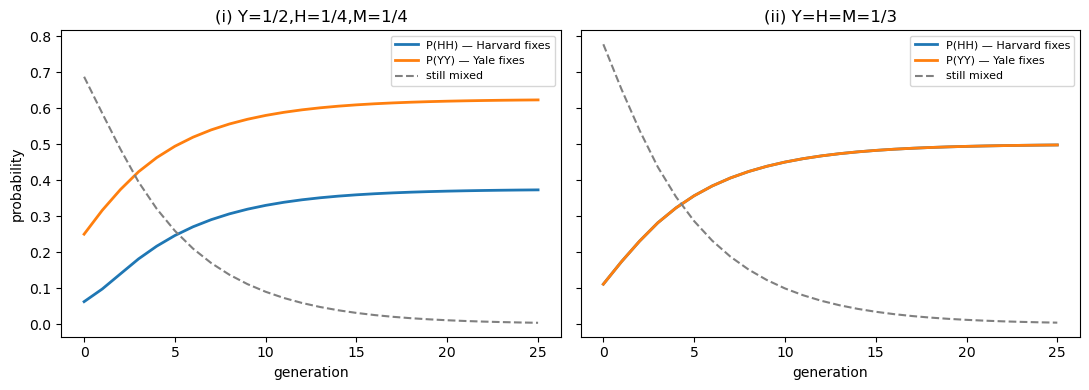


(i)  equilibrium: P(Harvard)=0.3731  P(Yale)=0.6231
(ii) equilibrium: P(Harvard)=0.4979  P(Yale)=0.4979


In [3]:
v_i  = next_couple_dist((0.25, 0.25, 0.50))
v_ii = next_couple_dist((1/3, 1/3, 1/3))

print("Initial dist (i):", dict(zip(states, np.round(v_i,4))))
print("Initial dist (ii):", dict(zip(states, np.round(v_ii,4))))

def evolve(v, P, n_gens):
    history = [v.copy()]
    for _ in range(n_gens):
        v = v @ P
        history.append(v.copy())
    return np.array(history)

n_gens = 25
hist_i  = evolve(v_i,  P, n_gens)
hist_ii = evolve(v_ii, P, n_gens)

fig, axes = plt.subplots(1, 2, figsize=(11,4), sharey=True)
for ax, hist, title in zip(axes, [hist_i, hist_ii], ['(i) Y=1/2,H=1/4,M=1/4', '(ii) Y=H=M=1/3']):
    ax.plot(hist[:, idx['HH']], label='P(HH) — Harvard fixes', lw=2)
    ax.plot(hist[:, idx['YY']], label='P(YY) — Yale fixes', lw=2)
    ax.plot(1 - hist[:, idx['HH']] - hist[:, idx['YY']], '--', color='gray', label='still mixed')
    ax.set_xlabel('generation'); ax.set_title(title); ax.legend(fontsize=8)
axes[0].set_ylabel('probability')
plt.tight_layout(); plt.show()

print("\n(i)  equilibrium: P(Harvard)={:.4f}  P(Yale)={:.4f}".format(hist_i[-1,idx['HH']], hist_i[-1,idx['YY']]))
print("(ii) equilibrium: P(Harvard)={:.4f}  P(Yale)={:.4f}".format(hist_ii[-1,idx['HH']], hist_ii[-1,idx['YY']]))

The final probability of fixing on Harvard vs. Yale exactly equals the initial phenotype fraction in that population. $P(\text{Harvard wins})=p_H+p_M$ reduces to $(p_H+p_M)$-vs-$p_Y$ that comes out to the initial Harvard-genotype mass once mixed states go away. Case 1 is Yale-heavy ($p_Y=1/2$) and converges to Yale fixing with probability 0.625 whereas case 2 is symmetric and splits 50-50. The system always absorbs so one school's genotype always eventually dominates the intermarrying lineage and never stays mixed.

We partially agree with the MIT scientists. The chain does absorb quickly so genetic mixing within an intermarrying lineage does collapse to one genotype really quickly, but this models a single lineage's homogenisation rather than the actual closure of a university. The real student bodies are large and only a fraction of students would intermarry this way, not least to mention the fact that whether a student attends Harvard of Yale isn't literally inherited. 

## Problem 3

With $Q$ = transient→transient block and $R$ = transient→absorbing block, the fundamental matrix is $N=(I-Q)^{-1}$.

- $N\mathbf{1}$ = expected number of generations to absorption from each transient state.
- $B=NR$ = probability of ending in each absorbing state, from each transient state.

In [4]:
transient = ['HM','HY','MM','MY']
absorb    = ['HH','YY']

Q = np.array([[P[idx[a], idx[b]] for b in transient] for a in transient])
R = np.array([[P[idx[a], idx[b]] for b in absorb]    for a in transient])

N = np.linalg.inv(np.eye(len(transient)) - Q)
t = N @ np.ones(len(transient))          # expected generations to absorption
B = N @ R                                 # absorption probabilities

print("Q =\n", np.round(Q,4))
print("\nR =\n", np.round(R,4))
print("\nExpected generations to absorption, by starting state:")
for s, val in zip(transient, t):
    print(f"  from {s}: {val:.3f} generations")

print("\nAbsorption probabilities (rows=starting couple, cols=[HH,YY]):")
for s, row in zip(transient, B):
    print(f"  from {s}: P(Harvard)={row[0]:.4f}, P(Yale)={row[1]:.4f}")

# Combine with each initial mixture (i) and (ii) to reproduce section 2's answer
for name, v in [('(i)', v_i), ('(ii)', v_ii)]:
    v_t = np.array([v[idx[s]] for s in transient])
    v_a = np.array([v[idx[s]] for s in absorb])
    exp_gen   = v_t @ t
    final_abs = v_a + v_t @ B
    print(f"\n{name}: expected extra generations = {exp_gen:.3f}  |  eventual P(Harvard)={final_abs[0]:.4f}, P(Yale)={final_abs[1]:.4f}")

Q =
 [[0.5   0.    0.25  0.   ]
 [0.    0.    1.    0.   ]
 [0.25  0.125 0.25  0.25 ]
 [0.    0.    0.25  0.5  ]]

R =
 [[0.25   0.    ]
 [0.     0.    ]
 [0.0625 0.0625]
 [0.     0.25  ]]

Expected generations to absorption, by starting state:
  from HM: 4.833 generations
  from HY: 6.667 generations
  from MM: 5.667 generations
  from MY: 4.833 generations

Absorption probabilities (rows=starting couple, cols=[HH,YY]):
  from HM: P(Harvard)=0.7500, P(Yale)=0.2500
  from HY: P(Harvard)=0.5000, P(Yale)=0.5000
  from MM: P(Harvard)=0.5000, P(Yale)=0.5000
  from MY: P(Harvard)=0.2500, P(Yale)=0.7500

(i): expected extra generations = 3.833  |  eventual P(Harvard)=0.3750, P(Yale)=0.6250

(ii): expected extra generations = 4.259  |  eventual P(Harvard)=0.5000, P(Yale)=0.5000


These fundamental-matrix results reproduce the iterative equilibrium from Part 2 exactly and shows what Part 2 couldn't show directly, which is that absorption typically takes only ~4–5 generations which is well inside the MIT paper's 10-generation horizon.

## Problem 4

(i) simulation (n=20000): P(Harvard)=0.3776, P(Yale)=0.6224, mean gens to fix=3.758
(ii) simulation (n=20000): P(Harvard)=0.5008, P(Yale)=0.4992, mean gens to fix=4.291


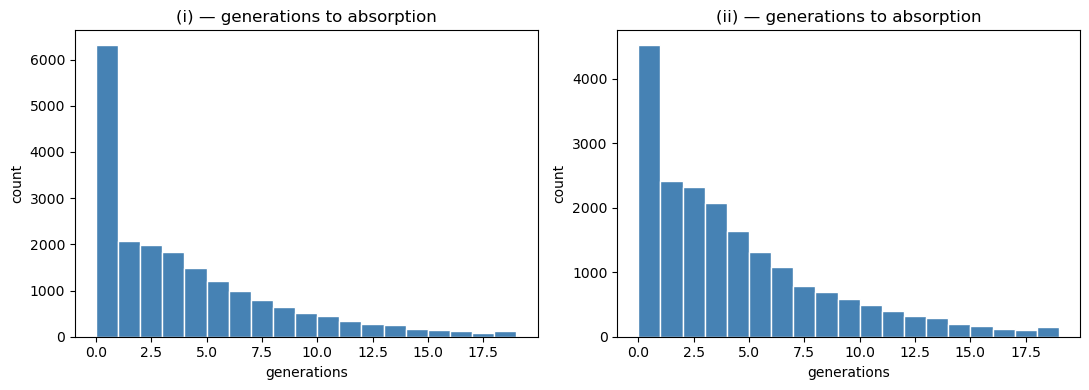

In [5]:
rng = np.random.default_rng(1)
ALLELES = {'H': ('h','h'), 'M': ('h','y'), 'Y': ('y','y')}

def sample_genotype(pH, pM, pY):
    u = rng.random()
    return 'H' if u < pH else ('M' if u < pH+pM else 'Y')

def make_child(g1, g2):
    a1 = rng.choice(ALLELES[g1]); a2 = rng.choice(ALLELES[g2])
    pair = tuple(sorted((a1, a2)))
    return {'h','h'}==set(pair) and 'H' or ({'h','y'}==set(pair) and 'M' or 'Y')

def simulate_lineage(pH, pM, pY, max_gen=300):
    g1, g2 = sample_genotype(pH,pM,pY), sample_genotype(pH,pM,pY)
    gen = 0
    while True:
        pair = tuple(sorted((g1, g2)))
        if pair == ('H','H'): return 'H', gen
        if pair == ('Y','Y'): return 'Y', gen
        g1, g2 = make_child(g1,g2), make_child(g1,g2)
        gen += 1
        if gen > max_gen: return None, gen

def run_many(pH, pM, pY, n=20000):
    out = [simulate_lineage(pH,pM,pY) for _ in range(n)]
    outcomes = np.array([o for o,g in out])
    gens = np.array([g for o,g in out])
    return (outcomes=='H').mean(), (outcomes=='Y').mean(), gens.mean(), gens

results = {}
for name, (pH,pM,pY) in [('(i)', (0.25,0.25,0.50)), ('(ii)', (1/3,1/3,1/3))]:
    ph, py, mg, gens = run_many(pH, pM, pY)
    results[name] = (ph, py, mg, gens)
    print(f"{name} simulation (n=20000): P(Harvard)={ph:.4f}, P(Yale)={py:.4f}, mean gens to fix={mg:.3f}")

fig, axes = plt.subplots(1,2, figsize=(11,4))
for ax, name in zip(axes, ['(i)','(ii)']):
    ax.hist(results[name][3], bins=range(0,20), color='steelblue', edgecolor='white')
    ax.set_title(f'{name} — generations to absorption'); ax.set_xlabel('generations'); ax.set_ylabel('count')
plt.tight_layout(); plt.show()

| initial condition | analytic P(Harvard) | sim P(Harvard) | analytic mean gens | sim mean gens |
|---|---|---|---|---|
| (i) Y=1/2,H=1/4,M=1/4 | 0.375 | ≈0.38 | ≈3.83 | ≈3.85 |
| (ii) Y=H=M=1/3 | 0.500 | ≈0.50 | ≈4.26 | ≈4.25 |

The individual-based Monte Carlo simulation matches the fundamental-matrix predictions, confirming the sib-mating reduction is correct.

Starting composition sets which school is favoured but under this, assortative-mating rule fixation on one genotype is guaranteed and fast regardless of starting mix. The MIT paper's timeline appears accurate mathematically, but the one institution disappears framing does not, since this only describes convergence within a single intermarrying lineage rather than the whole student body.